# Experiment 2: Tutor Personalization — R0 vs R1 (RQ1)

**Hypothesis H1:** FSLSM-based personalization in a PersonaRAG tutoring system improves response relevance and style conformance vs. a non-personalized RAG baseline.

**Conditions:**
- **R0 (Control):** Generic RAG — system prompt = "You are a helpful tutor."
- **R1 (Experimental):** FSLSM-personalized RAG — style-conditioned retrieval + generation

**Metrics:** SCS, RR, CR@5, ER, Engagement

In [4]:
%matplotlib inline
import sys, json
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name == "exp2_tutor_personalization" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config.constants import FSLSM_DIMENSIONS, FSLSM_DIM_LABELS

DIM_AXIS_LABELS = [f"{neg}/{pos}" for neg, pos in FSLSM_DIM_LABELS.values()]

RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load data
df = pd.read_csv(RESULTS_DIR / "exp2_session_metrics.csv")
with open(RESULTS_DIR / "exp2_results_summary.json") as f:
    summary = json.load(f)

df_r0 = df[df["mode"] == "R0"].copy()
df_r1 = df[df["mode"] == "R1"].copy()

print(f"Project root : {PROJECT_ROOT}")
print(f"Total rows   : {len(df)} (R0={len(df_r0)}, R1={len(df_r1)})")
print(f"Questions    : {df['question_id'].nunique()}")
print(f"Agents       : {df['agent_id'].nunique()}")
print(f"Profiles     : {df['profile_label'].nunique()}")

Project root : /Users/nyeinchanaung/Documents/GitHub/mcp-rag
Total rows   : 11520 (R0=5760, R1=5760)
Questions    : 72
Agents       : 80
Profiles     : 16


## 1. Overall Metrics Summary (R0 vs R1)

In [5]:
# Build summary table from significance results
rows = []
for metric in ["SCS", "RR", "CR@5", "CR@10", "ER", "Eng"]:
    if metric not in summary["significance"]:
        continue
    sig = summary["significance"][metric]
    rows.append({
        "Metric": metric,
        "R0 Mean": f"{sig['r0_mean']:.3f}",
        "R0 Std": f"{sig['r0_std']:.3f}",
        "R1 Mean": f"{sig['r1_mean']:.3f}",
        "R1 Std": f"{sig['r1_std']:.3f}",
        "Diff (R1-R0)": f"{sig['mean_diff']:+.3f}",
        "Cohen's d": f"{sig['cohens_d']:.3f}",
        "p-value": f"{sig['p_value']:.4f}",
        "Test": sig["test"],
        "Sig?": "Yes" if sig["significant"] else "No",
    })

df_summary = pd.DataFrame(rows)
df_summary.style.set_caption("Experiment 2 — R0 vs R1 Summary")

,Metric,R0 Mean,R0 Std,R1 Mean,R1 Std,Diff (R1-R0),Cohen's d,p-value,Test,Sig?
0,SCS,0.261,0.082,0.469,0.093,+0.208,2.367,0.0000,wilcoxon,Yes
1,RR,3.788,1.051,3.785,1.020,-0.003,-0.003,0.6830,wilcoxon,No
2,CR@5,0.159,0.205,0.155,0.197,-0.004,-0.022,0.0196,wilcoxon,Yes
3,CR@10,0.269,0.257,0.254,0.258,-0.016,-0.061,0.0000,wilcoxon,Yes
4,ER,0.340,0.467,0.333,0.464,-0.006,-0.013,0.0277,wilcoxon,Yes
5,Eng,3.247,0.482,3.890,0.374,+0.643,1.491,0.0000,wilcoxon,Yes


## 2. Metric Distributions — R0 vs R1 Box Plots

/var/folders/bq/vs89qf7n68vdtt4f5wyyxts40000gn/T/ipykernel_34389/3451458854.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="mode", y=col, palette={"R0": "#FF9800", "R1": "#2196F3"}, ax=ax)
/var/folders/bq/vs89qf7n68vdtt4f5wyyxts40000gn/T/ipykernel_34389/3451458854.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="mode", y=col, palette={"R0": "#FF9800", "R1": "#2196F3"}, ax=ax)
/var/folders/bq/vs89qf7n68vdtt4f5wyyxts40000gn/T/ipykernel_34389/3451458854.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=d

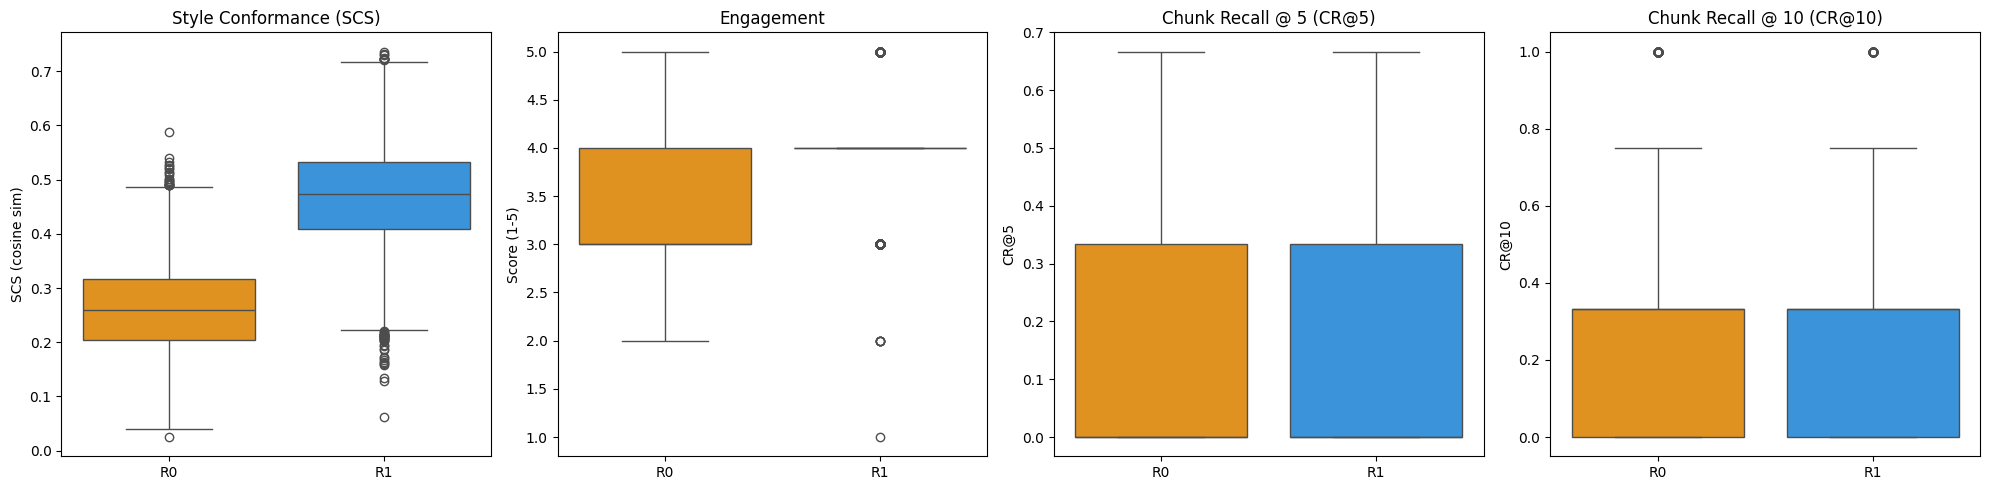

In [6]:
# ── 2.1 SCS, Engagement, CR@5, CR@10 Box Plots ────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, col, title, ylabel in zip(
    axes,
    ["scs", "engagement", "cr5", "cr10"],
    ["Style Conformance (SCS)", "Engagement", "Chunk Recall @ 5 (CR@5)", "Chunk Recall @ 10 (CR@10)"],
    ["SCS (cosine sim)", "Score (1-5)", "CR@5", "CR@10"],
):
    sns.boxplot(data=df, x="mode", y=col, palette={"R0": "#FF9800", "R1": "#2196F3"}, ax=ax)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "boxplots_scs_eng_cr5_cr10.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/bq/vs89qf7n68vdtt4f5wyyxts40000gn/T/ipykernel_34389/1299021419.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="mode", y="rr", palette={"R0": "#FF9800", "R1": "#2196F3"}, ax=axes[0])
/var/folders/bq/vs89qf7n68vdtt4f5wyyxts40000gn/T/ipykernel_34389/1299021419.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="mode", y="er", palette={"R0": "#FF9800", "R1": "#2196F3"}, ax=axes[1])


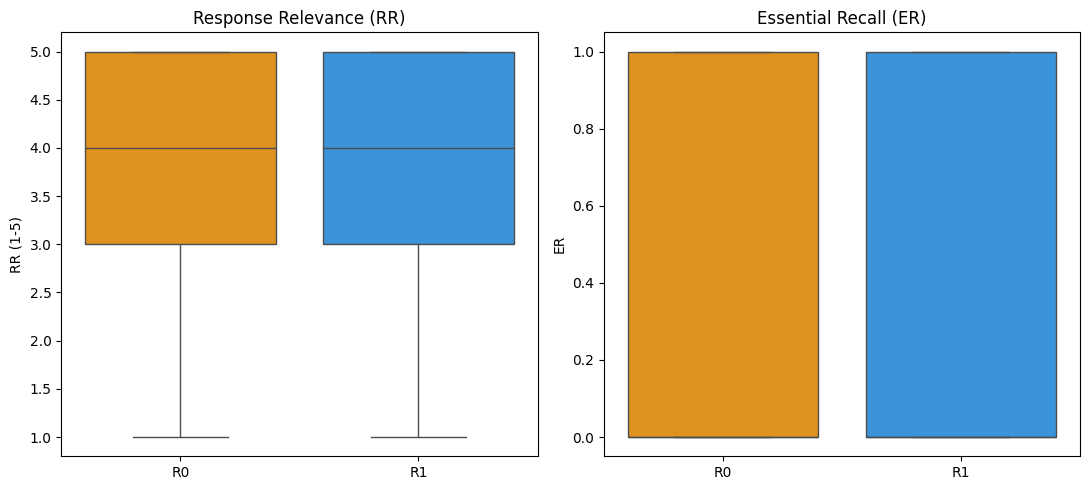

In [7]:
# ── 2.2 RR and ER Box Plots ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

if "rr" in df.columns and df["rr"].sum() > 0:
    sns.boxplot(data=df, x="mode", y="rr", palette={"R0": "#FF9800", "R1": "#2196F3"}, ax=axes[0])
    axes[0].set_title("Response Relevance (RR)")
    axes[0].set_ylabel("RR (1-5)")
else:
    axes[0].text(0.5, 0.5, "RR not computed\n(run without --skip-rr)", ha="center", va="center", fontsize=12)
    axes[0].set_title("Response Relevance (RR)")
axes[0].set_xlabel("")

sns.boxplot(data=df, x="mode", y="er", palette={"R0": "#FF9800", "R1": "#2196F3"}, ax=axes[1])
axes[1].set_title("Essential Recall (ER)")
axes[1].set_ylabel("ER")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "boxplots_rr_er.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. SCS by FSLSM Profile — Heatmap

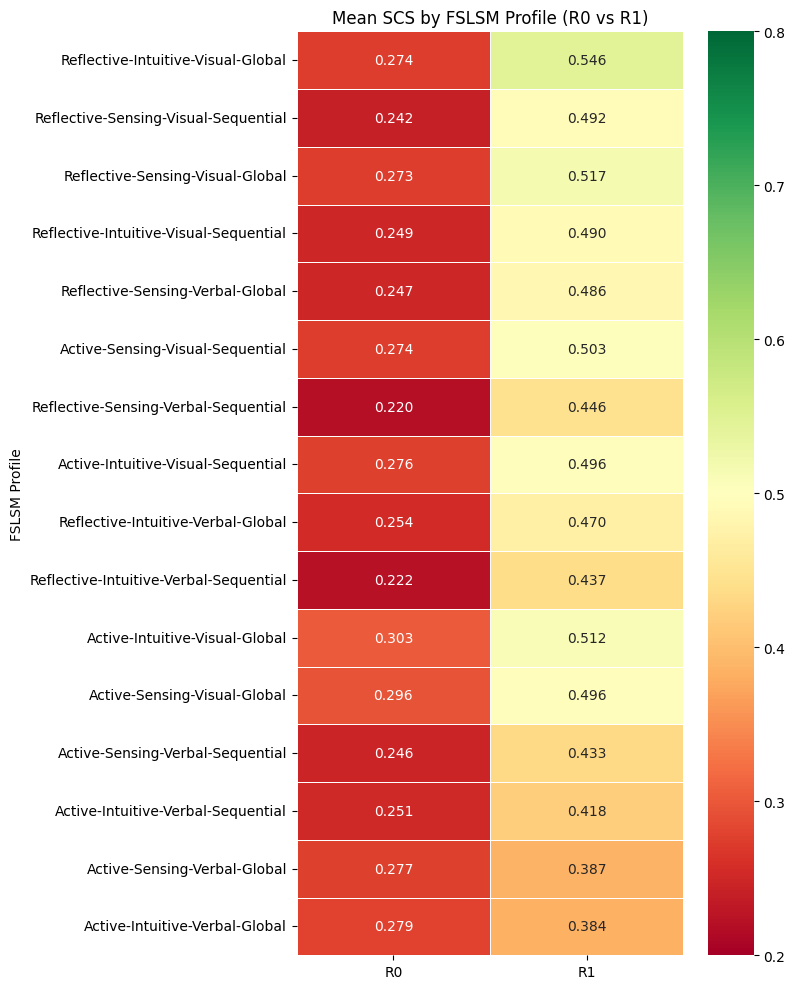


Biggest SCS uplift: Reflective-Intuitive-Visual-Global (+0.272)
Smallest SCS uplift: Active-Intuitive-Verbal-Global (+0.105)


In [8]:
# ── 3.  SCS Heatmap — 16 profiles × R0/R1 ────────────────────────────
profile_scs = df.groupby(["profile_label", "mode"])["scs"].mean().unstack(fill_value=0)
profile_scs = profile_scs[["R0", "R1"]]
profile_scs["Diff"] = profile_scs["R1"] - profile_scs["R0"]
profile_scs = profile_scs.sort_values("Diff", ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    profile_scs[["R0", "R1"]],
    annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.2, vmax=0.8,
    linewidths=0.5, ax=ax,
)
ax.set_title("Mean SCS by FSLSM Profile (R0 vs R1)", fontsize=12)
ax.set_ylabel("FSLSM Profile")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "scs_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nBiggest SCS uplift: {profile_scs['Diff'].idxmax()} ({profile_scs['Diff'].max():+.3f})")
print(f"Smallest SCS uplift: {profile_scs['Diff'].idxmin()} ({profile_scs['Diff'].min():+.3f})")

## 4. Per-Dimension Analysis

SCS and Engagement breakdown by each FSLSM dimension pole.

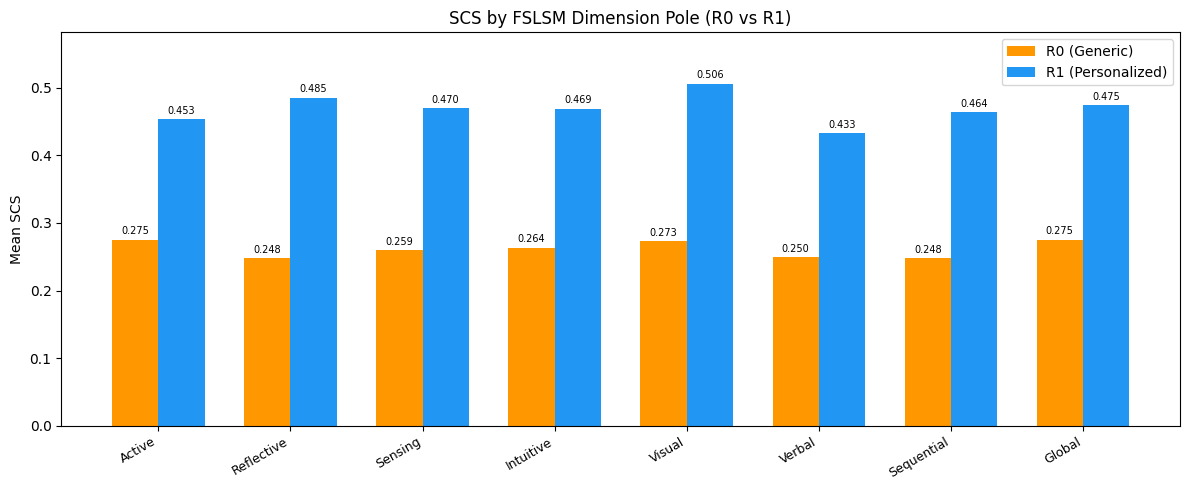

In [9]:
# ── 4.1 SCS by Dimension — Grouped Bar Chart ─────────────────────────
dim_data = summary.get("by_dimension", {})
dim_labels = []
scs_r0_vals = []
scs_r1_vals = []

for dim in FSLSM_DIMENSIONS:
    if dim not in dim_data:
        continue
    neg_label, pos_label = FSLSM_DIM_LABELS[dim]
    for pole_label in [neg_label, pos_label]:
        if pole_label in dim_data[dim]:
            d = dim_data[dim][pole_label]
            dim_labels.append(pole_label)
            scs_r0_vals.append(d["SCS_R0"])
            scs_r1_vals.append(d["SCS_R1"])

x = np.arange(len(dim_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, scs_r0_vals, width, label="R0 (Generic)", color="#FF9800")
bars2 = ax.bar(x + width/2, scs_r1_vals, width, label="R1 (Personalized)", color="#2196F3")

for bar, val in zip(bars1, scs_r0_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.3f}",
            ha="center", va="bottom", fontsize=7)
for bar, val in zip(bars2, scs_r1_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.3f}",
            ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(dim_labels, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Mean SCS")
ax.set_title("SCS by FSLSM Dimension Pole (R0 vs R1)")
ax.legend()
ax.set_ylim(0, max(scs_r0_vals + scs_r1_vals) * 1.15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "scs_by_dimension.png", dpi=150, bbox_inches="tight")
plt.show()

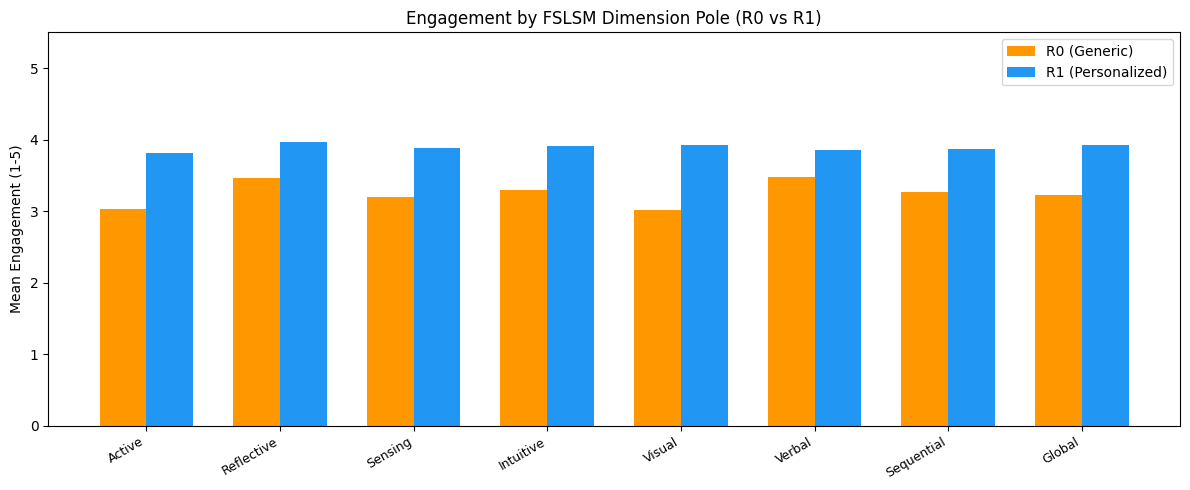

In [10]:
# ── 4.2 Engagement by Dimension — Grouped Bar Chart ──────────────────
eng_r0_vals = []
eng_r1_vals = []
eng_labels = []

for dim in FSLSM_DIMENSIONS:
    if dim not in dim_data:
        continue
    neg_label, pos_label = FSLSM_DIM_LABELS[dim]
    for pole_label in [neg_label, pos_label]:
        if pole_label in dim_data[dim]:
            d = dim_data[dim][pole_label]
            eng_labels.append(pole_label)
            eng_r0_vals.append(d["Eng_R0"])
            eng_r1_vals.append(d["Eng_R1"])

x = np.arange(len(eng_labels))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, eng_r0_vals, width, label="R0 (Generic)", color="#FF9800")
ax.bar(x + width/2, eng_r1_vals, width, label="R1 (Personalized)", color="#2196F3")

ax.set_xticks(x)
ax.set_xticklabels(eng_labels, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Mean Engagement (1-5)")
ax.set_title("Engagement by FSLSM Dimension Pole (R0 vs R1)")
ax.legend()
ax.set_ylim(0, 5.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "engagement_by_dimension.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Metrics Radar Chart — R0 vs R1

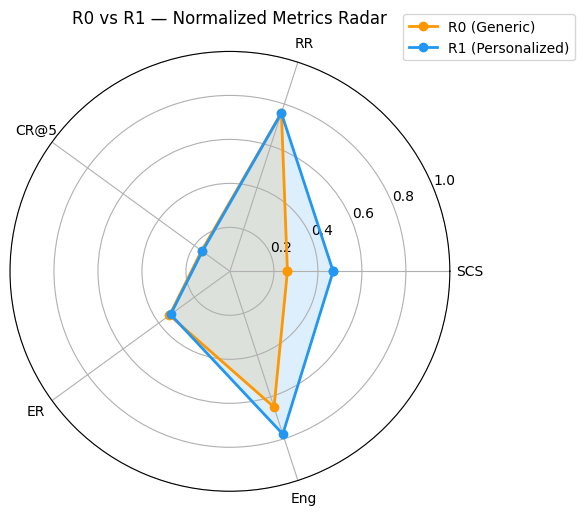

In [11]:
# ── 5. Radar chart comparing all metrics R0 vs R1 ────────────────────
metric_names = []
r0_means = []
r1_means = []

for m in ["SCS", "RR", "CR@5", "ER", "Eng"]:
    if m not in summary["metrics"]:
        continue
    metric_names.append(m)
    r0_means.append(summary["metrics"][m]["R0"]["mean"])
    r1_means.append(summary["metrics"][m]["R1"]["mean"])

# Normalize to [0, 1] for radar: SCS already ~[0,1], RR/Eng divide by 5, CR5/ER already [0,1]
scale = {"SCS": 1.0, "RR": 5.0, "CR@5": 1.0, "ER": 1.0, "Eng": 5.0}
r0_norm = [v / scale.get(m, 1) for m, v in zip(metric_names, r0_means)]
r1_norm = [v / scale.get(m, 1) for m, v in zip(metric_names, r1_means)]

angles = np.linspace(0, 2 * np.pi, len(metric_names), endpoint=False).tolist()
angles += angles[:1]
r0_norm += r0_norm[:1]
r1_norm += r1_norm[:1]

fig, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=(6, 6))
ax.plot(angles, r0_norm, "o-", color="#FF9800", label="R0 (Generic)", linewidth=2)
ax.fill(angles, r0_norm, alpha=0.15, color="#FF9800")
ax.plot(angles, r1_norm, "o-", color="#2196F3", label="R1 (Personalized)", linewidth=2)
ax.fill(angles, r1_norm, alpha=0.15, color="#2196F3")
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_names, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title("R0 vs R1 — Normalized Metrics Radar", pad=20, fontsize=12)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "metrics_radar.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Per-Question Analysis

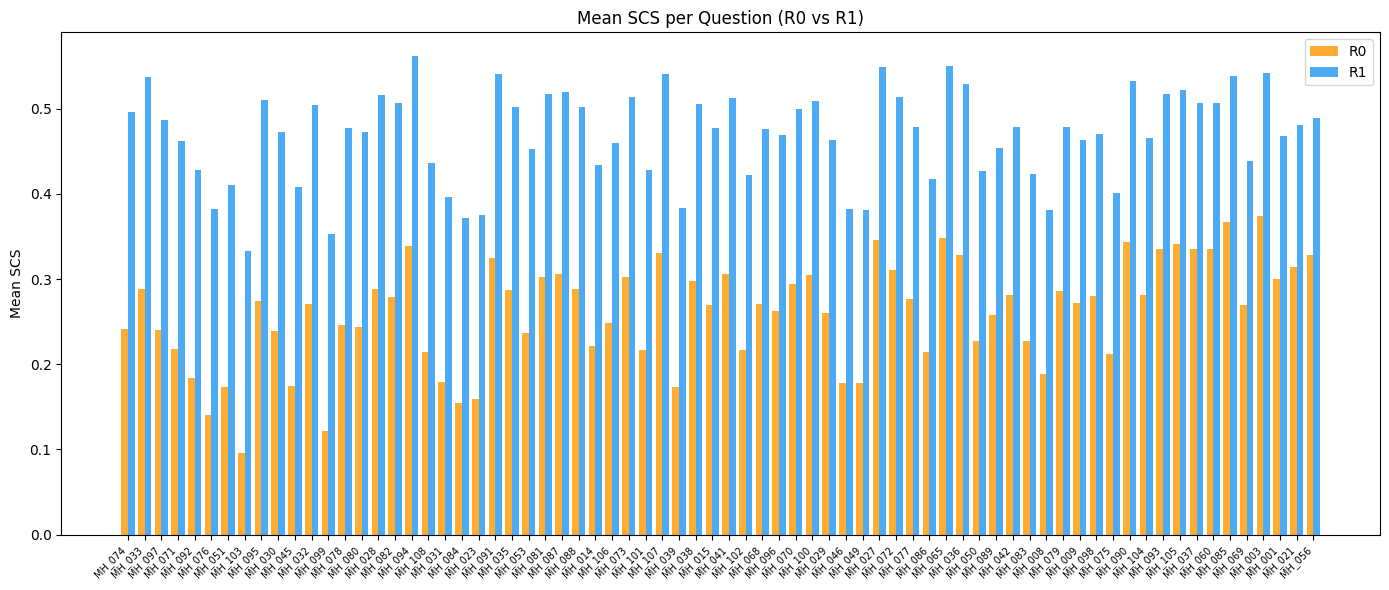

In [12]:
# ── 6.1 Mean SCS per question (R0 vs R1) ─────────────────────────────
q_scs = df.groupby(["question_id", "mode"])["scs"].mean().unstack(fill_value=0)
q_scs["Diff"] = q_scs["R1"] - q_scs["R0"]
q_scs = q_scs.sort_values("Diff", ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(q_scs))
ax.bar(x - 0.2, q_scs["R0"], 0.4, label="R0", color="#FF9800", alpha=0.8)
ax.bar(x + 0.2, q_scs["R1"], 0.4, label="R1", color="#2196F3", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(q_scs.index, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Mean SCS")
ax.set_title("Mean SCS per Question (R0 vs R1)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "scs_per_question.png", dpi=150, bbox_inches="tight")
plt.show()

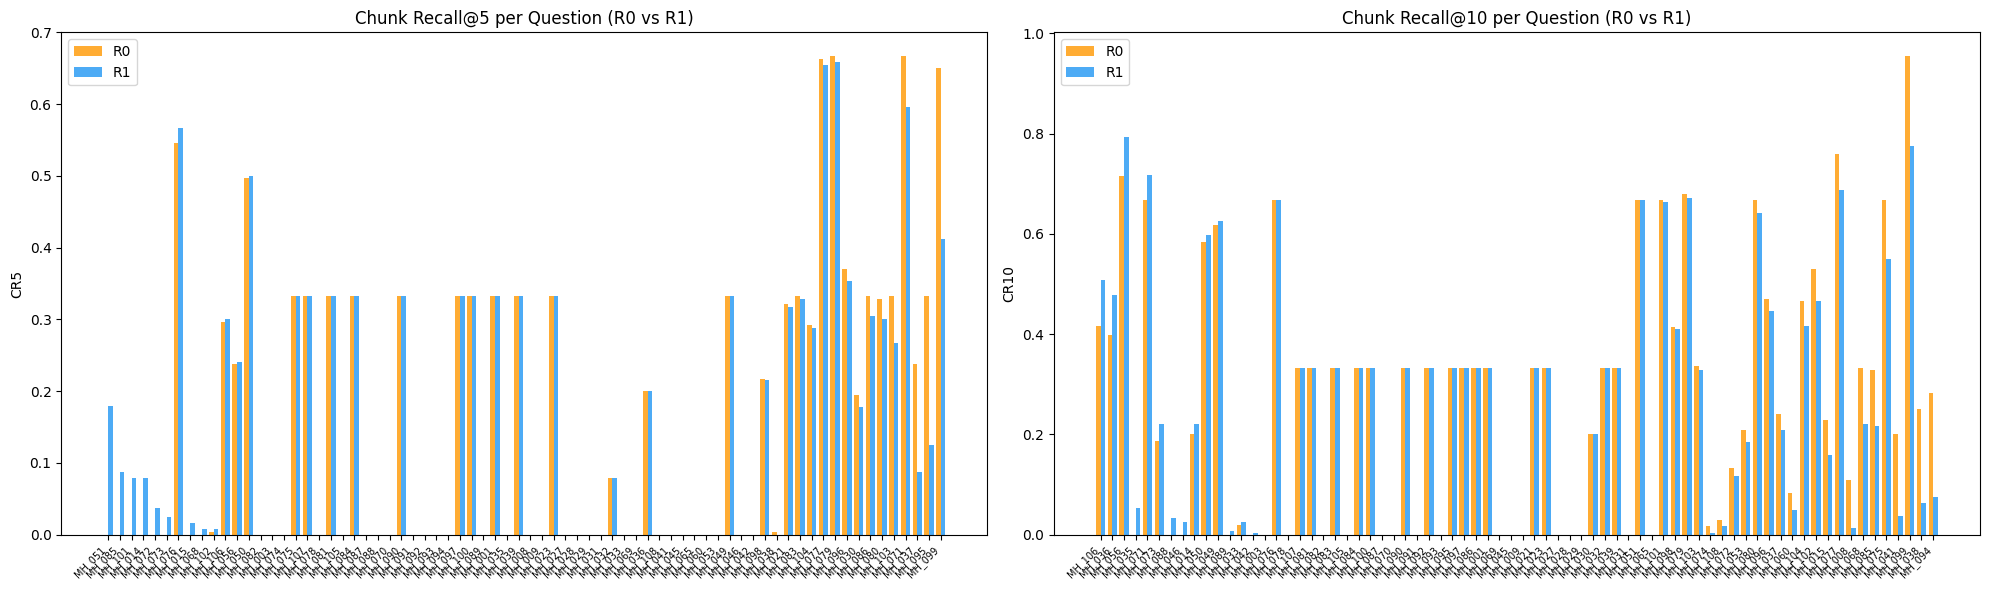

In [13]:
# ── 6.2 CR@5 and CR@10 per question ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, col, title in zip(
    axes,
    ["cr5", "cr10"],
    ["Chunk Recall@5 per Question (R0 vs R1)", "Chunk Recall@10 per Question (R0 vs R1)"],
):
    q_cr = df.groupby(["question_id", "mode"])[col].mean().unstack(fill_value=0)
    q_cr["Diff"] = q_cr["R1"] - q_cr["R0"]
    q_cr = q_cr.sort_values("Diff", ascending=False)
    x = np.arange(len(q_cr))
    ax.bar(x - 0.2, q_cr["R0"], 0.4, label="R0", color="#FF9800", alpha=0.8)
    ax.bar(x + 0.2, q_cr["R1"], 0.4, label="R1", color="#2196F3", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(q_cr.index, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel(col.upper())
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "cr5_cr10_per_question.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Cost and Latency Analysis

Total R0 cost: $12.80
Total R1 cost: $15.51
Total cost:    $28.31
Avg per session: $0.0025


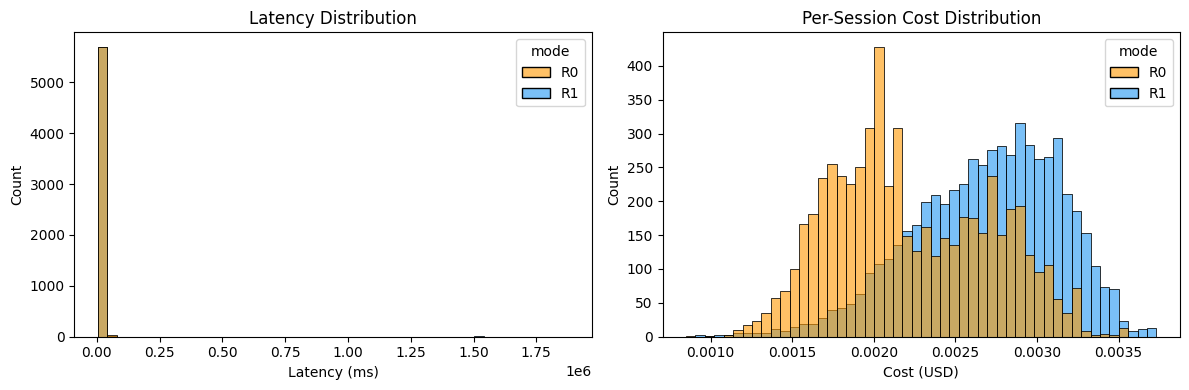


Median latency — R0: 11186ms, R1: 10902ms


In [14]:
# ── 7.1 Cost Summary ─────────────────────────────────────────────────
cost = summary.get("cost", {})
print(f"Total R0 cost: ${cost.get('total_r0_usd', 0):.2f}")
print(f"Total R1 cost: ${cost.get('total_r1_usd', 0):.2f}")
print(f"Total cost:    ${cost.get('total_r0_usd', 0) + cost.get('total_r1_usd', 0):.2f}")
print(f"Avg per session: ${cost.get('mean_per_session_usd', 0):.4f}")

# Latency distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="latency_ms", hue="mode", bins=50,
             palette={"R0": "#FF9800", "R1": "#2196F3"}, ax=axes[0], alpha=0.6)
axes[0].set_title("Latency Distribution")
axes[0].set_xlabel("Latency (ms)")

sns.histplot(data=df, x="tutor_cost", hue="mode", bins=50,
             palette={"R0": "#FF9800", "R1": "#2196F3"}, ax=axes[1], alpha=0.6)
axes[1].set_title("Per-Session Cost Distribution")
axes[1].set_xlabel("Cost (USD)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "latency_cost_dist.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMedian latency — R0: {df_r0['latency_ms'].median():.0f}ms, R1: {df_r1['latency_ms'].median():.0f}ms")

## 8. Engagement Distribution

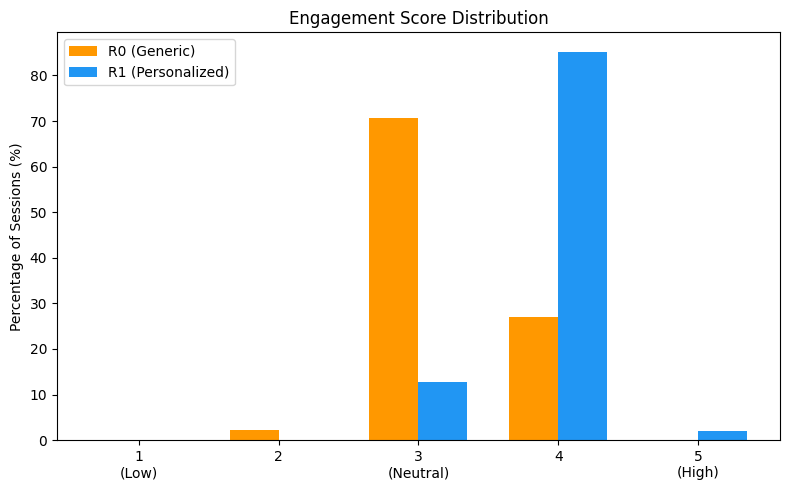

In [15]:
# ── 8. Engagement score distribution (discrete 1-5) ──────────────────
fig, ax = plt.subplots(figsize=(8, 5))

eng_counts = df.groupby(["mode", "engagement"]).size().unstack(fill_value=0)
eng_pct = eng_counts.div(eng_counts.sum(axis=1), axis=0) * 100

x = np.arange(5) + 1
width = 0.35
ax.bar(x - width/2, eng_pct.loc["R0"].reindex(range(1,6), fill_value=0),
       width, label="R0 (Generic)", color="#FF9800")
ax.bar(x + width/2, eng_pct.loc["R1"].reindex(range(1,6), fill_value=0),
       width, label="R1 (Personalized)", color="#2196F3")

ax.set_xticks(x)
ax.set_xticklabels(["1\n(Low)", "2", "3\n(Neutral)", "4", "5\n(High)"])
ax.set_ylabel("Percentage of Sessions (%)")
ax.set_title("Engagement Score Distribution")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "engagement_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. H1 Confirmation Checklist

| Condition | Requirement | Result |
|---|---|---|
| SCS(R1) > SCS(R0) | p < 0.05, uplift >= 0.20 | ? |
| RR(R1) ~ RR(R0) | within +/- 0.3 | ? |
| CR@5(R1) >= CR@5(R0) | higher or equal | ? |
| Engagement(R1) > Engagement(R0) | p < 0.05 | ? |

In [16]:
# ── 9. H1 Confirmation ───────────────────────────────────────────────
sig = summary["significance"]

checks = []

# SCS
if "SCS" in sig:
    scs_uplift = sig["SCS"]["mean_diff"]
    scs_sig = sig["SCS"]["significant"]
    checks.append(("SCS(R1) > SCS(R0), p < 0.05", scs_sig and scs_uplift > 0,
                    f"uplift={scs_uplift:+.3f}, p={sig['SCS']['p_value']:.4f}"))
    checks.append(("SCS uplift >= 0.20", scs_uplift >= 0.20,
                    f"uplift={scs_uplift:.3f}"))

# RR
if "RR" in sig:
    rr_diff = abs(sig["RR"]["mean_diff"])
    checks.append(("RR(R1) ~ RR(R0), within +/-0.3", rr_diff <= 0.3,
                    f"diff={sig['RR']['mean_diff']:+.3f}"))

# CR@5
if "CR@5" in sig:
    cr5_diff = sig["CR@5"]["mean_diff"]
    checks.append(("CR@5(R1) >= CR@5(R0)", cr5_diff >= 0,
                    f"diff={cr5_diff:+.3f}"))

# Engagement
if "Eng" in sig:
    eng_sig = sig["Eng"]["significant"]
    eng_diff = sig["Eng"]["mean_diff"]
    checks.append(("Engagement(R1) > Engagement(R0), p < 0.05",
                    eng_sig and eng_diff > 0,
                    f"diff={eng_diff:+.3f}, p={sig['Eng']['p_value']:.4f}"))

print("=" * 70)
print("H1 CONFIRMATION CHECKLIST")
print("=" * 70)
all_pass = True
for condition, passed, detail in checks:
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_pass = False
    print(f"  [{status}] {condition}")
    print(f"         {detail}")
print("=" * 70)
print(f"  H1 {'CONFIRMED' if all_pass else 'NOT CONFIRMED'}")
print("=" * 70)

H1 CONFIRMATION CHECKLIST
  [PASS] SCS(R1) > SCS(R0), p < 0.05
         uplift=+0.208, p=0.0000
  [PASS] SCS uplift >= 0.20
         uplift=0.208
  [PASS] RR(R1) ~ RR(R0), within +/-0.3
         diff=-0.003
  [FAIL] CR@5(R1) >= CR@5(R0)
         diff=-0.004
  [PASS] Engagement(R1) > Engagement(R0), p < 0.05
         diff=+0.643, p=0.0000
  H1 NOT CONFIRMED


## 10. Raw Response Comparison — R0 vs R1

Browse actual tutor responses side-by-side for matched pairs.  
Useful for qualitative review and understanding *why* SCS / RR differ.

In [17]:
# ── 10.1 Load raw sessions ────────────────────────────────────────────
import json
from pathlib import Path

RESULTS_DIR = Path("results")

def load_jsonl(path):
    sessions = []
    with open(path) as f:
        for line in f:
            if line.strip():
                sessions.append(json.loads(line))
    return sessions

print("Loading raw sessions...")
raw_r0 = load_jsonl(RESULTS_DIR / "raw_sessions_r0.jsonl")
raw_r1 = load_jsonl(RESULTS_DIR / "raw_sessions_r1.jsonl")

# Build lookup: (agent_id, question_id) -> session
lookup_r0 = {(s["agent_id"], s["question_id"]): s for s in raw_r0}
lookup_r1 = {(s["agent_id"], s["question_id"]): s for s in raw_r1}

# Matched pairs
matched_keys = set(lookup_r0.keys()) & set(lookup_r1.keys())
print(f"R0 sessions: {len(raw_r0)}")
print(f"R1 sessions: {len(raw_r1)}")
print(f"Matched pairs: {len(matched_keys)}")

# Available questions and agents
all_questions = sorted({k[1] for k in matched_keys})
all_agents    = sorted({k[0] for k in matched_keys})
print(f"\nQuestions ({len(all_questions)}): {all_questions[:10]} ...")
print(f"Agents    ({len(all_agents)}): {all_agents[:5]} ...")

Loading raw sessions...
R0 sessions: 5760
R1 sessions: 5760
Matched pairs: 5760

Questions (72): ['MH_001', 'MH_003', 'MH_008', 'MH_009', 'MH_014', 'MH_015', 'MH_021', 'MH_023', 'MH_027', 'MH_028'] ...
Agents    (80): ['P01_ActSenVisSeq_I01_beg', 'P01_ActSenVisSeq_I02_int', 'P01_ActSenVisSeq_I03_adv', 'P01_ActSenVisSeq_I04_gen', 'P01_ActSenVisSeq_I05_gen'] ...


In [21]:
# ── 10.2 Side-by-side response viewer ────────────────────────────────
# Set QUESTION_ID and AGENT_ID to any valid pair, then run this cell.
# Leave AGENT_ID = None to pick the first available agent for that question.

QUESTION_ID = "MH_009"   # e.g. "MH_001", "SH_005"
AGENT_ID    = "P10_RefSenVisGlo_I01_beg"        # e.g. "P01_ActSenVisSeq_I01_beg", or None for auto

from IPython.display import display, HTML

def show_pair(question_id, agent_id=None):
    # Pick agent if not specified
    if agent_id is None:
        candidates = [k for k in matched_keys if k[1] == question_id]
        if not candidates:
            print(f"No matched sessions found for question {question_id}")
            return
        agent_id = sorted(candidates)[0][0]

    key = (agent_id, question_id)
    s0 = lookup_r0.get(key)
    s1 = lookup_r1.get(key)

    if not s0 or not s1:
        print(f"Pair not found: agent={agent_id}, question={question_id}")
        return

    # Pull per-session metrics from df if available
    def get_metrics(agent, qid, mode):
        row = df[(df["agent_id"] == agent) & (df["question_id"] == qid) & (df["mode"] == mode)]
        if len(row):
            r = row.iloc[0]
            return f"SCS={r['scs']:.3f} | RR={r['rr']} | CR@5={r['cr5']:.2f} | ER={r['er']:.2f} | Eng={r['engagement']}"
        return "metrics not in CSV"

    m0 = get_metrics(agent_id, question_id, "R0")
    m1 = get_metrics(agent_id, question_id, "R1")

    fslsm = s1.get("fslsm_vector", {})
    profile = s1.get("profile_label", agent_id)

    html = f"""
    <div style="font-family:monospace; font-size:13px;">
        <h3>Question: {question_id}</h3>
        <p><b>Agent:</b> {agent_id} &nbsp;|&nbsp; <b>Profile:</b> {profile}</p>
        <p><b>FSLSM:</b> act_ref={fslsm.get('act_ref')} | sen_int={fslsm.get('sen_int')} |
           vis_ver={fslsm.get('vis_ver')} | seq_glo={fslsm.get('seq_glo')}</p>
        <p><b>Question:</b> {s0.get('question','')}</p>
        <hr>
        <table width="100%" style="border-collapse:collapse;">
          <tr>
            <th width="50%" style="background:#FF9800;color:white;padding:8px;">R0 — Generic RAG</th>
            <th width="50%" style="background:#2196F3;color:white;padding:8px;">R1 — FSLSM Personalized</th>
          </tr>
          <tr>
            <td style="padding:8px;vertical-align:top;font-size:11px;color:#888;">{m0}</td>
            <td style="padding:8px;vertical-align:top;font-size:11px;color:#888;">{m1}</td>
          </tr>
          <tr>
            <td style="padding:10px;vertical-align:top;border:1px solid #ddd;white-space:pre-wrap;">{s0.get('response','')}</td>
            <td style="padding:10px;vertical-align:top;border:1px solid #ddd;white-space:pre-wrap;">{s1.get('response','')}</td>
          </tr>
        </table>
        <hr>
        <b>System prompt used (R1):</b>
        <pre style="background:#f5f5f5;padding:10px;font-size:11px;white-space:pre-wrap;">{s1.get('system_prompt_used','')[:1500]}...</pre>
        <b>Reformulated query (R1):</b> {s1.get('reformulated_query','')}
    </div>
    """
    display(HTML(html))

show_pair(QUESTION_ID, AGENT_ID)

R0 — Generic RAG,R1 — FSLSM Personalized
SCS=0.342 | RR=3 | CR@5=0.00 | ER=0.00 | Eng=3,SCS=0.420 | RR=3 | CR@5=0.00 | ER=0.00 | Eng=3


In [19]:
# ── 10.3 Find interesting cases automatically ─────────────────────────
rows = []
for key in matched_keys:
    agent_id, question_id = key
    r0_row = df[(df["agent_id"] == agent_id) & (df["question_id"] == question_id) & (df["mode"] == "R0")]
    r1_row = df[(df["agent_id"] == agent_id) & (df["question_id"] == question_id) & (df["mode"] == "R1")]
    if r0_row.empty or r1_row.empty:
        continue
    r0, r1 = r0_row.iloc[0], r1_row.iloc[0]
    rows.append({
        "agent_id":    agent_id,
        "question_id": question_id,
        "profile":     r1["profile_label"],
        "scs_r0":      r0["scs"],   "scs_r1":  r1["scs"],  "scs_diff":  r1["scs"] - r0["scs"],
        "rr_r0":       r0["rr"],    "rr_r1":   r1["rr"],   "rr_diff":   r1["rr"] - r0["rr"],
        "eng_r0":      r0["engagement"], "eng_r1": r1["engagement"], "eng_diff": r1["engagement"] - r0["engagement"],
        "cr5_r0":      r0["cr5"],   "cr5_r1":  r1["cr5"],  "cr5_diff":  r1["cr5"] - r0["cr5"],
        "cr10_r0":     r0["cr10"],  "cr10_r1": r1["cr10"], "cr10_diff": r1["cr10"] - r0["cr10"],
    })

pairs_df = pd.DataFrame(rows)

print("=== Top 10: Biggest SCS improvement (R1 >> R0) ===")
display(pairs_df.nlargest(10, "scs_diff")[
    ["question_id", "agent_id", "profile", "scs_r0", "scs_r1", "scs_diff", "rr_r0", "rr_r1", "eng_r0", "eng_r1"]
].round(3).reset_index(drop=True))

print("\n=== Top 10: Biggest SCS drop (R1 < R0) ===")
display(pairs_df.nsmallest(10, "scs_diff")[
    ["question_id", "agent_id", "profile", "scs_r0", "scs_r1", "scs_diff", "rr_r0", "rr_r1"]
].round(3).reset_index(drop=True))

print("\n=== Top 10: Biggest RR drop in R1 ===")
display(pairs_df.nsmallest(10, "rr_diff")[
    ["question_id", "agent_id", "profile", "rr_r0", "rr_r1", "rr_diff", "scs_r0", "scs_r1"]
].round(3).reset_index(drop=True))

print("\n=== Top 10: CR@5 improvement (R1 > R0) ===")
display(pairs_df.nlargest(10, "cr5_diff")[
    ["question_id", "agent_id", "profile", "cr5_r0", "cr5_r1", "cr5_diff", "cr10_r0", "cr10_r1", "cr10_diff"]
].round(3).reset_index(drop=True))

print("\n=== Top 10: CR@10 improvement (R1 > R0) ===")
display(pairs_df.nlargest(10, "cr10_diff")[
    ["question_id", "agent_id", "profile", "cr5_r0", "cr5_r1", "cr5_diff", "cr10_r0", "cr10_r1", "cr10_diff"]
].round(3).reset_index(drop=True))

=== Top 10: Biggest SCS improvement (R1 >> R0) ===


,question_id,agent_id,profile,scs_r0,scs_r1,scs_diff,rr_r0,rr_r1,eng_r0,eng_r1
0,MH_053,P14_RefIntVisGlo_I05_gen,Reflective-Intuitive-Visual-Global,0.204,0.695,0.492,3,3,3,4
1,MH_051,P10_RefSenVisGlo_I02_int,Reflective-Sensing-Visual-Global,0.137,0.618,0.481,5,3,3,4
2,MH_045,P10_RefSenVisGlo_I04_gen,Reflective-Sensing-Visual-Global,0.150,0.622,0.471,3,5,3,4
3,MH_074,P02_ActSenVisGlo_I03_adv,Active-Sensing-Visual-Global,0.190,0.657,0.467,3,3,3,4
4,MH_099,P01_ActSenVisSeq_I03_adv,Active-Sensing-Visual-Sequential,0.081,0.547,0.466,4,5,3,5
5,MH_065,P01_ActSenVisSeq_I01_beg,Active-Sensing-Visual-Sequential,0.201,0.665,0.465,2,3,3,4
6,MH_074,P10_RefSenVisGlo_I01_beg,Reflective-Sensing-Visual-Global,0.212,0.674,0.462,3,3,3,4
7,MH_032,P14_RefIntVisGlo_I01_beg,Reflective-Intuitive-Visual-Global,0.233,0.686,0.454,4,5,3,4
8,MH_099,P14_RefIntVisGlo_I05_gen,Reflective-Intuitive-Visual-Global,0.091,0.532,0.440,5,5,3,4
9,MH_103,P02_ActSenVisGlo_I04_gen,Active-Sensing-Visual-Global,0.116,0.556,0.440,5,5,3,4



=== Top 10: Biggest SCS drop (R1 < R0) ===


,question_id,agent_id,profile,scs_r0,scs_r1,scs_diff,rr_r0,rr_r1
0,MH_008,P07_ActIntVerSeq_I02_int,Active-Intuitive-Verbal-Sequential,0.297,0.161,-0.136,5,5
1,MH_050,P10_RefSenVisGlo_I02_int,Reflective-Sensing-Visual-Global,0.437,0.301,-0.136,5,5
2,MH_107,P08_ActIntVerGlo_I01_beg,Active-Intuitive-Verbal-Global,0.514,0.378,-0.136,5,5
3,MH_060,P04_ActSenVerGlo_I05_gen,Active-Sensing-Verbal-Global,0.493,0.363,-0.130,4,3
4,MH_008,P13_RefIntVisSeq_I05_gen,Reflective-Intuitive-Visual-Sequential,0.187,0.061,-0.126,4,2
5,MH_051,P04_ActSenVerGlo_I04_gen,Active-Sensing-Verbal-Global,0.299,0.194,-0.105,4,4
6,MH_072,P04_ActSenVerGlo_I02_int,Active-Sensing-Verbal-Global,0.527,0.428,-0.098,3,3
7,MH_072,P08_ActIntVerGlo_I01_beg,Active-Intuitive-Verbal-Global,0.456,0.374,-0.082,3,3
8,MH_079,P08_ActIntVerGlo_I04_gen,Active-Intuitive-Verbal-Global,0.444,0.364,-0.081,3,3
9,MH_021,P08_ActIntVerGlo_I01_beg,Active-Intuitive-Verbal-Global,0.459,0.381,-0.078,2,3



=== Top 10: Biggest RR drop in R1 ===


,question_id,agent_id,profile,rr_r0,rr_r1,rr_diff,scs_r0,scs_r1
0,MH_073,P14_RefIntVisGlo_I02_int,Reflective-Intuitive-Visual-Global,5,1,-4,0.317,0.603
1,MH_073,P05_ActIntVisSeq_I02_int,Active-Intuitive-Visual-Sequential,5,2,-3,0.334,0.466
2,MH_073,P02_ActSenVisGlo_I02_int,Active-Sensing-Visual-Global,5,2,-3,0.380,0.502
3,MH_073,P03_ActSenVerSeq_I04_gen,Active-Sensing-Verbal-Sequential,5,2,-3,0.223,0.466
4,MH_009,P05_ActIntVisSeq_I03_adv,Active-Intuitive-Visual-Sequential,5,2,-3,0.220,0.411
5,MH_073,P13_RefIntVisSeq_I02_int,Reflective-Intuitive-Visual-Sequential,5,2,-3,0.333,0.588
6,MH_073,P06_ActIntVisGlo_I05_gen,Active-Intuitive-Visual-Global,5,2,-3,0.327,0.563
7,MH_073,P08_ActIntVerGlo_I04_gen,Active-Intuitive-Verbal-Global,5,2,-3,0.242,0.401
8,MH_009,P07_ActIntVerSeq_I03_adv,Active-Intuitive-Verbal-Sequential,5,2,-3,0.301,0.453
9,MH_073,P10_RefSenVisGlo_I05_gen,Reflective-Sensing-Visual-Global,5,2,-3,0.361,0.580



=== Top 10: CR@5 improvement (R1 > R0) ===


,question_id,agent_id,profile,cr5_r0,cr5_r1,cr5_diff,cr10_r0,cr10_r1,cr10_diff
0,MH_076,P15_RefIntVerSeq_I04_gen,Reflective-Intuitive-Verbal-Sequential,0.333,0.667,0.333,0.667,0.667,0.000
1,MH_076,P05_ActIntVisSeq_I03_adv,Active-Intuitive-Visual-Sequential,0.333,0.667,0.333,0.667,0.667,0.000
2,MH_076,P07_ActIntVerSeq_I01_beg,Active-Intuitive-Verbal-Sequential,0.333,0.667,0.333,0.667,0.667,0.000
3,MH_076,P03_ActSenVerSeq_I03_adv,Active-Sensing-Verbal-Sequential,0.333,0.667,0.333,0.667,0.667,0.000
4,MH_099,P02_ActSenVisGlo_I01_beg,Active-Sensing-Visual-Global,0.333,0.667,0.333,0.667,0.667,0.000
5,MH_076,P08_ActIntVerGlo_I05_gen,Active-Intuitive-Verbal-Global,0.333,0.667,0.333,0.667,0.667,0.000
6,MH_076,P06_ActIntVisGlo_I03_adv,Active-Intuitive-Visual-Global,0.333,0.667,0.333,0.667,0.667,0.000
7,MH_096,P08_ActIntVerGlo_I03_adv,Active-Intuitive-Verbal-Global,0.333,0.667,0.333,0.333,0.667,0.333
8,MH_076,P08_ActIntVerGlo_I03_adv,Active-Intuitive-Verbal-Global,0.333,0.667,0.333,0.667,0.667,0.000
9,MH_096,P01_ActSenVisSeq_I03_adv,Active-Sensing-Visual-Sequential,0.333,0.667,0.333,0.333,0.667,0.333



=== Top 10: CR@10 improvement (R1 > R0) ===


,question_id,agent_id,profile,cr5_r0,cr5_r1,cr5_diff,cr10_r0,cr10_r1,cr10_diff
0,MH_072,P09_RefSenVisSeq_I01_beg,Reflective-Sensing-Visual-Sequential,0.00,0.000,0.000,0.00,0.667,0.667
1,MH_072,P05_ActIntVisSeq_I04_gen,Active-Intuitive-Visual-Sequential,0.00,0.333,0.333,0.00,0.667,0.667
2,MH_072,P09_RefSenVisSeq_I03_adv,Reflective-Sensing-Visual-Sequential,0.00,0.000,0.000,0.00,0.667,0.667
3,MH_072,P10_RefSenVisGlo_I03_adv,Reflective-Sensing-Visual-Global,0.00,0.000,0.000,0.00,0.667,0.667
4,MH_014,P05_ActIntVisSeq_I01_beg,Active-Intuitive-Visual-Sequential,0.00,0.000,0.000,0.00,0.667,0.667
5,MH_072,P03_ActSenVerSeq_I01_beg,Active-Sensing-Verbal-Sequential,0.00,0.000,0.000,0.00,0.667,0.667
6,MH_056,P12_RefSenVerGlo_I05_gen,Reflective-Sensing-Verbal-Global,0.00,0.250,0.250,0.25,0.750,0.500
7,MH_056,P07_ActIntVerSeq_I05_gen,Active-Intuitive-Verbal-Sequential,0.00,0.250,0.250,0.25,0.750,0.500
8,MH_056,P08_ActIntVerGlo_I04_gen,Active-Intuitive-Verbal-Global,0.25,0.250,0.000,0.25,0.750,0.500
9,MH_056,P16_RefIntVerGlo_I03_adv,Reflective-Intuitive-Verbal-Global,0.25,0.250,0.000,0.25,0.750,0.500


In [20]:
# ── 10.4 Quick browse: show pair from the interesting cases table ──────
# After running 10.3, copy any (question_id, agent_id) from the tables above
# and paste them here to view the full responses side-by-side.

QUESTION_ID = pairs_df.nlargest(1, "scs_diff").iloc[0]["question_id"]  # auto: best SCS improvement
AGENT_ID    = pairs_df.nlargest(1, "scs_diff").iloc[0]["agent_id"]

show_pair(QUESTION_ID, AGENT_ID)

R0 — Generic RAG,R1 — FSLSM Personalized
SCS=0.204 | RR=3 | CR@5=0.00 | ER=0.00 | Eng=3,SCS=0.695 | RR=3 | CR@5=0.00 | ER=0.00 | Eng=4
